In [3]:
import pandas as pd

In [4]:
matches_df = pd.read_csv('../data/matches.csv')
matches_df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
matches_df.shape

(1095, 20)

In [6]:
#phase 2: Data Cleaning & Checking for missing values

In [7]:
matches_df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [8]:
matches_df = matches_df.dropna(subset=['winner'])
matches_df.shape

(1090, 20)

In [9]:
matches_df[matches_df['city'].isnull()][['venue','city']].head(10)

,venue,city
399,Sharjah Cricket Stadium,NaN
402,Dubai International Cricket Stadium,NaN
403,Dubai International Cricket Stadium,NaN
404,Sharjah Cricket Stadium,NaN
406,Sharjah Cricket Stadium,NaN
407,Dubai International Cricket Stadium,NaN
408,Sharjah Cricket Stadium,NaN
409,Dubai International Cricket Stadium,NaN
410,Dubai International Cricket Stadium,NaN
413,Sharjah Cricket Stadium,NaN


In [10]:
matches_df.loc[matches_df['venue']== 'Sharjah Cricket Stadium','city'] = 'Sharjah'
matches_df.loc[matches_df['venue']== 'Dubai International Cricket Stadium','city'] = "Dubai"
matches_df['city'].isnull().sum()

np.int64(0)

In [11]:
matches_df['team1'].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [16]:
team_mappings ={
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
    'Kings XI Punjab':'Punjab Kings',
    'Delhi Daredevils':'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'}
matches_df['team1'] = matches_df['team1'].replace(team_mappings)
matches_df['team2'] = matches_df['team2'].replace(team_mappings)

matches_df['team1'].unique()

array(['Royal Challengers Bengaluru', 'Punjab Kings', 'Delhi Capitals',
       'Mumbai Indians', 'Kolkata Knight Riders', 'Rajasthan Royals',
       'Deccan Chargers', 'Chennai Super Kings', 'Kochi Tuskers Kerala',
       'Pune Warriors', 'Sunrisers Hyderabad', 'Gujarat Lions',
       'Rising Pune Supergiants', 'Lucknow Super Giants',
       'Gujarat Titans'], dtype=object)

In [13]:
#phase 3: Exploratory Data Analysis

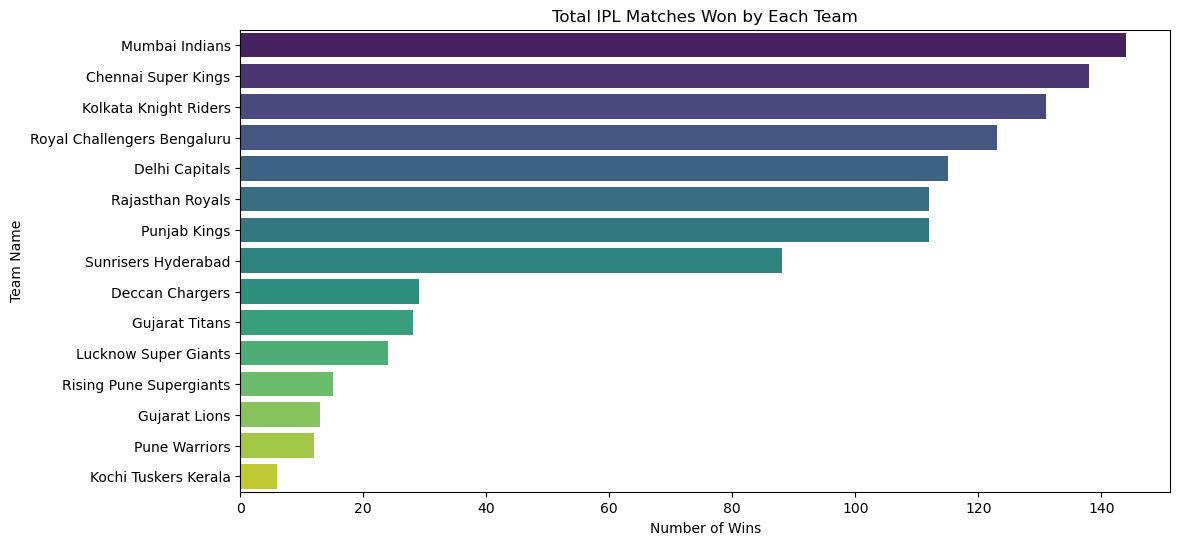

In [17]:
team_mappings ={
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
    'Kings XI Punjab':'Punjab Kings',
    'Delhi Daredevils':'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'}

matches_df['winner'] = matches_df['winner'].replace(team_mappings)

team_wins = matches_df['winner'].value_counts()

import matplotlib.pyplot as plt
import seaborn as sns

team_wins = matches_df['winner'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(x=team_wins.values,y = team_wins.index,hue= team_wins.index,palette = 'viridis',legend = False)

plt.title('Total IPL Matches Won by Each Team')
plt.xlabel('Number of Wins')
plt.ylabel('Team Name')

plt.show()

In [18]:
toss_bias = matches_df['toss_decision'].value_counts(normalize=True) * 100
round(toss_bias,2)

toss_decision
field    64.22
bat      35.78
Name: proportion, dtype: float64

In [20]:
matches_df.to_csv('../data/matches_cleaned.csv',index = False)